# seai - gas monthly

https://www.seai.ie/data-and-insights/seai-statistics/monthly-energy-data/gas-monthly

https://public.tableau.com/app/profile/lee.carroll/viz/Gas-EnhancedMonthlyPanels/6

Tj - terajoule = 0.278GWh



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
filename = "L_Full Data_data.csv"

In [3]:
df = pd.read_csv(filename)
df.head()

,Year of Period,Month of Period,Unit,Source,Supplied
0,2011,April,TJ,Indigenous,464.0
1,2012,April,TJ,Indigenous,621.0
2,2013,April,TJ,Indigenous,643.0
3,2014,April,TJ,Indigenous,532.0
4,2015,April,TJ,Indigenous,450.0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year of Period   576 non-null    int64  
 1   Month of Period  576 non-null    str    
 2   Unit             576 non-null    str    
 3   Source           576 non-null    str    
 4   Supplied         575 non-null    float64
dtypes: float64(1), int64(1), str(3)
memory usage: 22.6 KB


In [5]:
df["Source"].unique()

<StringArray>
['Indigenous', 'Imports', 'Stock Draw']
Length: 3, dtype: str

In [6]:
df["Unit"].unique()

<StringArray>
['TJ']
Length: 1, dtype: str

In [7]:
data = df.groupby(["Year of Period", "Month of Period"])
data.head()

,Year of Period,Month of Period,Unit,Source,Supplied
0,2011,April,TJ,Indigenous,464.0
1,2012,April,TJ,Indigenous,621.0
2,2013,April,TJ,Indigenous,643.0
3,2014,April,TJ,Indigenous,532.0
4,2015,April,TJ,Indigenous,450.0
...,...,...,...,...,...
571,2025,July,TJ,Stock Draw,0.0
572,2025,September,TJ,Stock Draw,0.0
573,2025,October,TJ,Stock Draw,0.0
574,2025,November,TJ,Stock Draw,NaN


<Axes: xlabel='Year of Period,Month of Period'>

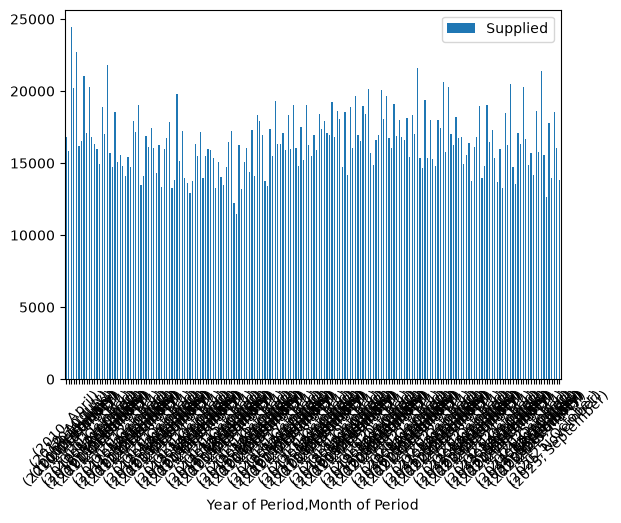

In [8]:
data.sum().plot(rot=45, kind="bar")

In [9]:
data2025 = df[df["Year of Period"] == 2025]
data2025.head(100)

,Year of Period,Month of Period,Unit,Source,Supplied
14,2025,April,TJ,Indigenous,3025.0
30,2025,August,TJ,Indigenous,2956.0
46,2025,December,TJ,Indigenous,2782.0
62,2025,February,TJ,Indigenous,2909.0
78,2025,January,TJ,Indigenous,3113.0
94,2025,July,TJ,Indigenous,2951.0
110,2025,June,TJ,Indigenous,2243.0
126,2025,March,TJ,Indigenous,3127.0
142,2025,May,TJ,Indigenous,3075.0
158,2025,November,TJ,Indigenous,2761.0


In [10]:
months = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]

In [11]:
data2025 = data2025.groupby("Month of Period", as_index=False).sum()
data2025.head()

,Month of Period,Year of Period,Unit,Source,Supplied
0,April,6075,TJTJTJ,IndigenousImportsStock Draw,15689.0
1,August,6075,TJTJTJ,IndigenousImportsStock Draw,14200.0
2,December,6075,TJTJTJ,IndigenousImportsStock Draw,18590.0
3,February,6075,TJTJTJ,IndigenousImportsStock Draw,15784.0
4,January,6075,TJTJTJ,IndigenousImportsStock Draw,21408.0


In [12]:
data2025['Month of Period'] = pd.Categorical(data2025['Month of Period'], categories=months, ordered=True) 
data2025 = data2025.sort_values(by="Month of Period")
data2025.head(36)

,Month of Period,Year of Period,Unit,Source,Supplied
4,January,6075,TJTJTJ,IndigenousImportsStock Draw,21408.0
3,February,6075,TJTJTJ,IndigenousImportsStock Draw,15784.0
7,March,6075,TJTJTJ,IndigenousImportsStock Draw,17790.0
0,April,6075,TJTJTJ,IndigenousImportsStock Draw,15689.0
8,May,6075,TJTJTJ,IndigenousImportsStock Draw,13949.0
6,June,6075,TJTJTJ,IndigenousImportsStock Draw,12675.0
5,July,6075,TJTJTJ,IndigenousImportsStock Draw,15546.0
1,August,6075,TJTJTJ,IndigenousImportsStock Draw,14200.0
11,September,6075,TJTJTJ,IndigenousImportsStock Draw,13796.0
10,October,6075,TJTJTJ,IndigenousImportsStock Draw,16074.0


<Axes: xlabel='Month of Period'>

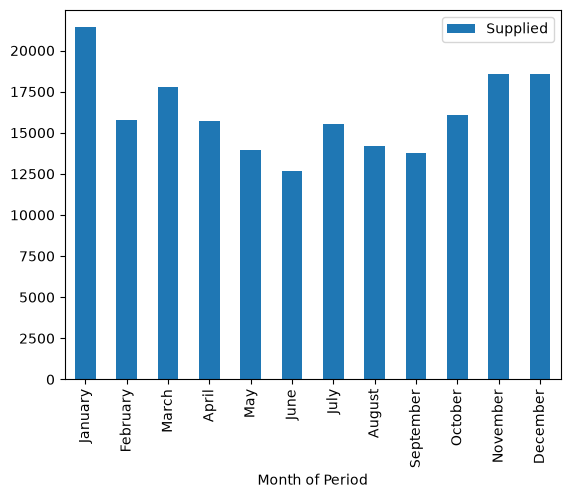

In [13]:
data2025.plot(x="Month of Period", y="Supplied", kind="bar")